<a href="https://colab.research.google.com/github/enilt/langgraph-alura/blob/main/Aula_07_MultiAg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 07 — Multiagentes: Assistente de E-mail (triagem + agente ReAct) com Groq

Montamos um assistente que **classifica e-mails** (ignorar / notificar / responder) e, quando é preciso responder, aciona um **agente ReAct** com ferramentas (escrever e-mail, agendar reunião, checar agenda).

> Convenções mantidas (com **Groq**):
> - Modelo **Groq** `openai/gpt-oss-120b` via `langchain-groq` (com `reasoning_effort` explícito)
> - Chave automática (`GROQ_API_KEY`) via Secrets do Colab / `.env` / colada
>
> **Adaptação importante:** o notebook original importa os prompts de um arquivo `prompts.py`.
> Como no Colab esse arquivo não existe, os prompts foram **embutidos** aqui (Seção 4),
> mantendo exatamente o mesmo conteúdo. Assim não é preciso subir nenhum arquivo extra.

## 1. Instalação das dependências

In [1]:
%pip install -U langgraph langchain langchain-groq python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.7/164.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 13.0 MB/s eta 0:00:00
  Attempting uninstall: python-dotenv
    Found existing installation: python-dotenv 1.2.3
    Uninstalling python-dotenv-1.2.3:
      Successfully uninstalled python-dotenv-1.2.3
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.11
    Uninstalling langgraph-1.2.11:
      Successfully uninstalled langgraph-1.2.11
  Attempting uninstall: langchain
    Found existing installation: langchain 1.4.0
    Uninstalling langchain-1.4.0:
      Successfully uninstalled langchain-1.4.0


## 2. Chave de API (sem digitar toda vez)

Esta aula usa **apenas o Groq** (não usa Tavily). Escolha uma opção:
1. **Colar** o valor na variável abaixo.
2. **Secrets do Colab** (🔑): crie `GROQ_API_KEY` com "Notebook access"; deixe a variável vazia.
3. **Arquivo `.env`** (local).

In [2]:
import os

GROQ_API_KEY = ""   # ex: "gsk_..." (opcional; vazio = Secrets do Colab / .env)


def resolver_chave(nome, valor_manual):
    if valor_manual:
        return valor_manual.strip()
    try:
        from google.colab import userdata
        try:
            v = userdata.get(nome)
            if v and v.strip():
                print(f"[OK] '{nome}' encontrada nos Secrets do Colab.")
                return v.strip()
            else:
                print(f"[VAZIO] '{nome}' existe nos Secrets, mas está vazia.")
        except userdata.SecretNotFoundError:
            print(f"[NAO EXISTE] '{nome}' não encontrada nos Secrets. Confira o NOME exato '{nome}'.")
        except userdata.NotebookAccessError:
            print(f"[SEM ACESSO] '{nome}' existe, mas 'Notebook access' NÃO está ativado.")
        except Exception as e:
            print(f"[ERRO] ao ler '{nome}' do Colab: {type(e).__name__}: {e}")
    except ImportError:
        pass
    try:
        from dotenv import load_dotenv
        load_dotenv()
    except ImportError:
        pass
    v = os.getenv(nome)
    return v.strip() if v else None


groq_key = resolver_chave("GROQ_API_KEY", GROQ_API_KEY)
if not groq_key:
    raise ValueError(
        "GROQ_API_KEY ausente. Cole na variável acima, ou crie o segredo no Colab "
        "(nome exato + Notebook access), ou defina no .env."
    )
os.environ["GROQ_API_KEY"] = groq_key
print("Chave carregada com sucesso!")

[OK] 'GROQ_API_KEY' encontrada nos Secrets do Colab.
Chave carregada com sucesso!


## 3. Perfil da usuária, regras de triagem e e-mail de exemplo

In [3]:
profile = {
    "name": "Sarah",
    "full_name": "Sarah Chen",
    "user_profile_background": "Engenheira de software sênior liderando uma equipe de 5 desenvolvedores",
}

In [4]:
prompt_instructions = {
    "triage_rules": {
        "ignore": "Newsletters de marketing, e-mails de spam, comunicados gerais da empresa",
        "notify": "Membro da equipe doente, notificações do sistema de build, atualizações de status de projeto",
        "respond": "Perguntas diretas de membros da equipe, solicitações de reunião, relatórios de bugs críticos",
    },
    "agent_instructions": "Use estas ferramentas quando apropriado para ajudar a gerenciar as tarefas de Sarah de forma eficiente."
}

In [5]:
email = {
    "from": "Alice Smith <alice.smith@company.com>",
    "to": "Sarah Chen <sarah.chen@company.com>",
    "subject": "Dúvida rápida sobre a documentação da API",
    "body": """
Olá Sarah,

Eu estava revisando a documentação da API para o novo serviço de autenticação e notei que alguns endpoints parecem estar faltando nas especificações. Você poderia me ajudar a esclarecer se isso foi intencional ou se devemos atualizar a documentação?

Especificamente, estou procurando por:
- /auth/refresh
- - /auth/validate

Obrigada!
Alice""",
}

## 4. Prompts (embutidos)

Estes são exatamente os prompts que ficavam no arquivo `prompts.py` do curso. Definimos aqui para o notebook rodar sozinho no Colab.

In [6]:
agent_system_prompt = """
< Função >
Você é o(a) assistente executivo(a) de {full_name}. Você é um(a) assistente executivo(a) de alto nível que se preocupa com o desempenho de {name} o máximo possível.
</ Função >

< Ferramentas >
Você tem acesso às seguintes ferramentas para ajudar a gerenciar as comunicações e a agenda de {name}:

1. write_email(to, subject, content) - Envia e-mails para destinatários especificados
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day) - Agenda reuniões no calendário
3. check_calendar_availability(day) - Verifica os horários disponíveis em um determinado dia
</ Ferramentas >

< Instruções >
{instructions}
</ Instruções >
"""

triage_system_prompt = """
< Função >
Você é o(a) assistente executivo(a) de {full_name}. Você é um(a) assistente executivo(a) de alto nível que se preocupa com o desempenho de {name} o máximo possível.
</ Função >

< Contexto >
{user_profile_background}.
</ Contexto >

< Instruções >
{name} recebe muitos e-mails. Sua tarefa é categorizar cada e-mail em uma de três categorias:

1. IGNORAR - E-mails que não valem a pena responder ou monitorar
2. NOTIFICAR - Informações importantes que {name} deve saber, mas que não exigem uma resposta
3. RESPONDER - E-mails que precisam de uma resposta direta de {name}

Classifique o e-mail abaixo em uma dessas categorias.

</ Instruções >

< Regras >
E-mails que não valem a pena responder:
{triage_no}

Existem também outras coisas sobre as quais {name} deve saber, mas que não exigem uma resposta por e-mail. Para estes, você deve notificar {name} (usando a resposta `notify`). Exemplos incluem:
{triage_notify}

E-mails que valem a pena responder:
{triage_email}
</ Regras >

< Exemplos >
{examples}
</ Exemplos >
"""

triage_user_prompt = """
Por favor, determine como lidar com a conversa de e-mail abaixo:

De: {author}
Para: {to}
Assunto: {subject}
{email_thread}"""

## 5. Modelo (Groq), schema de roteamento e roteador estruturado

In [7]:
from pydantic import BaseModel, Field
from typing_extensions import TypedDict, Literal, Annotated

from langchain_groq import ChatGroq

# Um único modelo Groq reutilizado no roteador e no agente ReAct
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    reasoning_effort="low",
    max_retries=6,
)

In [8]:
class Router(BaseModel):
    """Analisa o e-mail não lido e o roteia de acordo com seu conteúdo."""

    reasoning: str = Field(
        description="Raciocínio passo a passo por trás da classificação."
    )
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="A classificação de um e-mail: 'ignore' para e-mails irrelevantes, "
        "'notify' para informações importantes que não precisam de resposta, "
        "'respond' para e-mails que precisam de uma resposta",
    )

In [9]:
# json_mode: robusto com o gpt-oss no Groq (evita o erro de "tool choice").
llm_router = llm.with_structured_output(Router, method="json_mode")

# Instrução de formato anexada ao prompt do sistema (necessária no json_mode).
INSTRUCAO_JSON_ROUTER = (
    '\n\nIMPORTANTE: responda APENAS com um objeto JSON válido, sem texto extra, '
    'no formato: {"reasoning": "seu raciocínio passo a passo", '
    '"classification": "ignore" ou "notify" ou "respond"}.'
)

## 6. Testando a triagem em um e-mail

In [10]:
system_prompt = triage_system_prompt.format(
    full_name=profile["full_name"],
    name=profile["name"],
    examples=None,
    user_profile_background=profile["user_profile_background"],
    triage_no=prompt_instructions["triage_rules"]["ignore"],
    triage_notify=prompt_instructions["triage_rules"]["notify"],
    triage_email=prompt_instructions["triage_rules"]["respond"],
)

user_prompt = triage_user_prompt.format(
    author=email["from"],
    to=email["to"],
    subject=email["subject"],
    email_thread=email["body"],
)

result = llm_router.invoke(
    [
        {"role": "system", "content": system_prompt + INSTRUCAO_JSON_ROUTER},
        {"role": "user", "content": user_prompt},
    ]
)
print(result)

reasoning='Alice, likely a team member, asks a direct question about missing API endpoints and needs clarification. This requires Sarah to reply with information or action, so it falls under emails that need a direct response.' classification='respond'


## 7. Ferramentas do agente

In [11]:
from langchain_core.tools import tool


@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Escreve e envia um e-mail."""
    # Resposta de placeholder - em um aplicativo real, enviaria o e-mail
    return f"E-mail enviado para {to} com o assunto '{subject}'"


@tool
def schedule_meeting(
    attendees: list[str],
    subject: str,
    duration_minutes: int,
    preferred_day: str
) -> str:
    """Agenda uma reunião no calendário."""
    return f"Reunião '{subject}' agendada para {preferred_day} com {len(attendees)} participantes"


@tool
def check_calendar_availability(day: str) -> str:
    """Verifica a disponibilidade do calendário para um determinado dia."""
    return f"Horários disponíveis em {day}: 9:00 AM, 2:00 PM, 4:00 PM"


tools = [write_email, schedule_meeting, check_calendar_availability]

## 8. Agente ReAct (prebuilt) com o prompt do sistema

In [12]:
from langgraph.prebuilt import create_react_agent


def create_prompt(state):
    return [
        {
            "role": "system",
            "content": agent_system_prompt.format(
                instructions=prompt_instructions["agent_instructions"],
                **profile
            )
        }
    ] + state['messages']


agent = create_react_agent(
    model=llm,
    tools=tools,
    prompt=create_prompt,
)

/tmp/ipykernel_3678/298550452.py:16: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


## 9. Testando o agente diretamente

In [13]:
response = agent.invoke(
    {"messages": [{
        "role": "user",
        "content": "qual é minha disponibilidade para terça-feira?"
    }]}
)
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

Sua agenda para terça‑feira está livre nos seguintes horários:

- 09:00 – 10:00  
- 14:00 – 15:00  
- 16:00 – 17:00  

Se precisar marcar alguma reunião ou reservar algum desses períodos, é só me avisar!


## 10. Grafo completo: triagem que decide se aciona o agente

In [14]:
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.types import Command
from typing import Literal
from IPython.display import Image, display


class State(TypedDict):
    email_input: dict
    messages: Annotated[list, add_messages]

In [15]:
def triage_router(state: State) -> Command[Literal["response_agent", "__end__"]]:
    author = state['email_input']['author']
    to = state['email_input']['to']
    subject = state['email_input']['subject']
    email_thread = state['email_input']['email_thread']

    system_prompt = triage_system_prompt.format(
        full_name=profile["full_name"],
        name=profile["name"],
        user_profile_background=profile["user_profile_background"],
        triage_no=prompt_instructions["triage_rules"]["ignore"],
        triage_notify=prompt_instructions["triage_rules"]["notify"],
        triage_email=prompt_instructions["triage_rules"]["respond"],
        examples=None
    )
    user_prompt = triage_user_prompt.format(
        author=author,
        to=to,
        subject=subject,
        email_thread=email_thread
    )
    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt + INSTRUCAO_JSON_ROUTER},
            {"role": "user", "content": user_prompt},
        ]
    )
    if result.classification == "respond":
        print("📧 Classificação: RESPONDER - Este e-mail requer uma resposta")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Responda ao e-mail {state['email_input']}",
                }
            ]
        }
    elif result.classification == "ignore":
        print("🚫 Classificação: IGNORAR - Este e-mail pode ser ignorado com segurança")
        update = None
        goto = END
    elif result.classification == "notify":
        print("🔔 Classificação: NOTIFICAR - Este e-mail contém informações importantes")
        update = None
        goto = END
    else:
        raise ValueError(f"Classificação inválida: {result.classification}")
    return Command(goto=goto, update=update)

In [16]:
email_agent = StateGraph(State)
email_agent = email_agent.add_node("triage_router", triage_router)
email_agent = email_agent.add_node("response_agent", agent)
email_agent = email_agent.add_edge(START, "triage_router")
email_agent = email_agent.compile()

## 11. Visualização do grafo

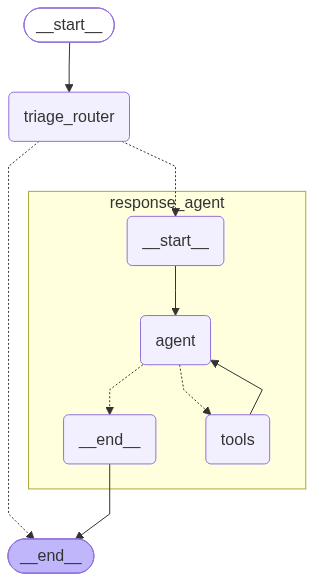

In [ ]:
display(Image(email_agent.get_graph(xray=True).draw_mermaid_png()))

## 12. Executando o assistente

In [17]:
# E-mail de marketing -> deve ser IGNORADO
email_input = {
    "author": "Equipe de Marketing <marketing@amazingdeals.com>",
    "to": "Sarah Chen <sarah.chen@company.com>",
    "subject": "🔥 OFERTA EXCLUSIVA: Desconto por Tempo Limitado em Ferramentas para Desenvolvedores! 🔥",
    "email_thread": """Prezado(a) Desenvolvedor(a),

Não perca esta oportunidade INCRÍVEL!

🚀 POR TEMPO LIMITADO, obtenha 80% DE DESCONTO em nosso Pacote Premium para Desenvolvedores!

✨ RECURSOS:
- Preenchimento de código revolucionário com IA
- Ambiente de desenvolvimento baseado em nuvem
- Suporte ao cliente 24/7
- E muito mais!

💰 Preço Normal: R$ 999/mês
🎉 SEU PREÇO ESPECIAL: Apenas R$ 199/mês!

🕒 Corra! Esta oferta expira em:
APENAS 24 HORAS!

Clique aqui para resgatar seu desconto: https://amazingdeals.com/special-offer

Atenciosamente,
Equipe de Marketing
---
Para cancelar a inscrição, clique aqui
""",
}

response = email_agent.invoke({"email_input": email_input})

🚫 Classificação: IGNORAR - Este e-mail pode ser ignorado com segurança


In [18]:
# E-mail da Alice -> deve ser RESPONDIDO (aciona o agente)
email_input = {
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "Sarah Chen <sarah.chen@company.com>",
    "subject": "Dúvida rápida sobre a documentação da API",
    "email_thread": """Olá Sarah,

Eu estava revisando a documentação da API para o novo serviço de autenticação e notei que alguns endpoints parecem estar faltando nas especificações. Você poderia me ajudar a esclarecer se isso foi intencional ou se devemos atualizar a documentação?

Especificamente, estou procurando por:
- /auth/refresh
- /auth/validate

Obrigada!
Alice""",
}

response = email_agent.invoke({"email_input": email_input})

📧 Classificação: RESPONDER - Este e-mail requer uma resposta


In [19]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Responda ao e-mail {'author': 'Alice Smith <alice.smith@company.com>', 'to': 'Sarah Chen <sarah.chen@company.com>', 'subject': 'Dúvida rápida sobre a documentação da API', 'email_thread': 'Olá Sarah,\n\nEu estava revisando a documentação da API para o novo serviço de autenticação e notei que alguns endpoints parecem estar faltando nas especificações. Você poderia me ajudar a esclarecer se isso foi intencional ou se devemos atualizar a documentação?\n\nEspecificamente, estou procurando por:\n- /auth/refresh\n- /auth/validate\n\nObrigada!\nAlice'}
================================== Ai Message ==================================
Tool Calls:
  write_email (fc_8eb94219-ed4c-4bf4-a2b4-a3f6267945e5)
 Call ID: fc_8eb94219-ed4c-4bf4-a2b4-a3f6267945e5
  Args:
    content: Olá Alice,

Obrigado por trazer essa questão. Os endpoints /auth/refresh e /auth/validate estão realmente ausentes na versão atual da documentação